In [1]:
!pip install transformers datasets accelerate torch scikit-learn pandas

In [2]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset


In [4]:
data = pd.read_csv("final_dataset.csv")
data = data.dropna()

# Use subset for faster training (optional)
data = data.sample(50000, random_state=42)

data.head()


,text,label
52747,Nunes Stepping Aside Temporarily from Russia P...,1
47239,South Korea to hold summit with China on Satur...,1
19315,After FBI Reopens Hillary Email Case Trump Sup...,0
26816,Trump to meet congressional leaders next week ...,1
21977,FBI: 27.5 Million Gun Background Checks in 201...,1


In [5]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    data["text"], data["label"], test_size=0.2, random_state=42
)


In [6]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")


In [ ]:
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length")

train_dataset = Dataset.from_dict({
    "text": list(train_texts),
    "label": list(train_labels)
})

test_dataset = Dataset.from_dict({
    "text": list(test_texts),
    "label": list(test_labels)
})

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])
test_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])


In [8]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.to(device)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

In [9]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_dir="./logs",
    eval_strategy="no",
    fp16=torch.cuda.is_available()
)


In [10]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
)

trainer.train()


Step,Training Loss
500,0.162300
1000,0.107800
1500,0.088400
2000,0.083000
2500,0.076500


TrainOutput(global_step=2500, training_loss=0.10361239776611328, metrics={'train_runtime': 1116.2984, 'train_samples_per_second': 35.833, 'train_steps_per_second': 2.24, 'total_flos': 5298695946240000.0, 'train_loss': 0.10361239776611328, 'epoch': 1.0})

In [11]:
predictions = trainer.predict(test_dataset)
print(predictions.metrics)


{'test_loss': 0.07733764499425888, 'test_runtime': 85.0914, 'test_samples_per_second': 117.521, 'test_steps_per_second': 7.345}


In [12]:
model.save_pretrained("distilbert_fake_news_model")
tokenizer.save_pretrained("distilbert_fake_news_model")

print("Model saved successfully")


Model saved successfully


In [13]:
from sklearn.metrics import accuracy_score

preds = predictions.predictions.argmax(axis=1)

accuracy = accuracy_score(test_labels, preds)

print("Accuracy:", accuracy)

Accuracy: 0.9612


In [14]:
import numpy as np
from sklearn.metrics import accuracy_score

# predicted probabilities
pred_probs = predictions.predictions

# predicted class
pred_labels = np.argmax(pred_probs, axis=1)

# true labels
true_labels = test_labels

print("DistilBERT Accuracy:", accuracy_score(true_labels, pred_labels))

DistilBERT Accuracy: 0.9612


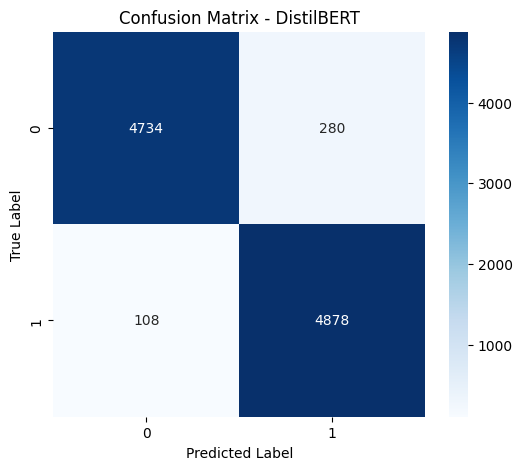

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DistilBERT")

plt.show()

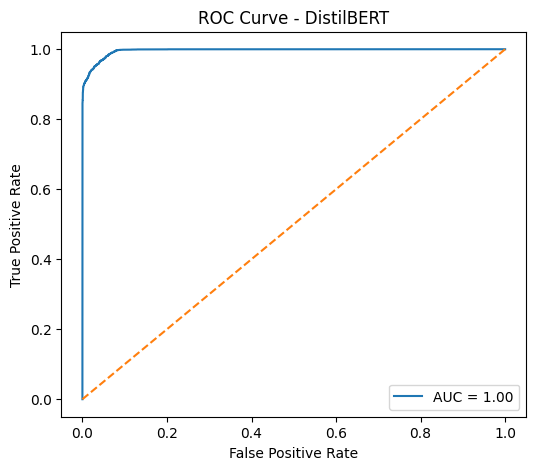

In [16]:
from sklearn.metrics import roc_curve, auc

# probability of real news
probs = pred_probs[:,1]

fpr, tpr, thresholds = roc_curve(true_labels, probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DistilBERT")
plt.legend()

plt.show()

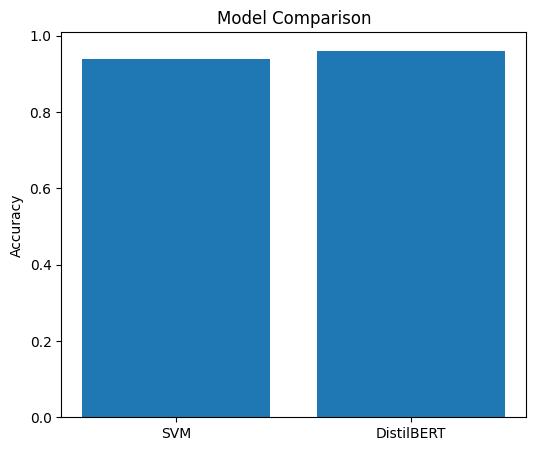

In [17]:
models = ["SVM","DistilBERT"]

accuracy_scores = [0.94, accuracy_score(true_labels, pred_labels)]

plt.figure(figsize=(6,5))
plt.bar(models, accuracy_scores)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()